# SSD MobileNet V2 (320×320) — PhenoBench finetune

Fine-tunes **SSD MobileNet V2 (320×320)** for **multi-class crop-vs-weed instance
detection** on the PhenoBench dataset, and publishes a self-contained
`finetune/` artifact (the fp32 base model used downstream for post-training
quantization and as the QAT starting point). The dedicated `ptq/` directory is
reserved for the companion PTQ (QAT-parity) runs.

- **Detector:** a single-shot detector (SSD) head on a MobileNetV2 backbone (no feature pyramid).
- **Framework:** TensorFlow Object Detection API (TF 2.11), fine-tuned from the
  COCO-2017 checkpoint.
- **Task:** two foreground classes (`crop`, `weed`); detecting just the `weed` class is the single-class (`sc`) variant, not this one.

All training, curve and export plumbing is delegated to the shared
`agri_vision_edge.tfod_trainer` package, so this notebook only carries the
experiment-specific pieces: the `FineTuneConfig`, the `ExperimentManifest`,
publication-quality curves, and qualitative evaluation. The same run can be
driven head-less from Python — see `notebooks/finetuning.py` for an interactive
marimo front-end over the identical `FinetuneRunConfig` + `run_finetune`.

## Output contract (`/kaggle/working`)

On completion the working directory holds exactly:

```
/kaggle/working/
├── manifest.json
└── finetune/
    ├── checkpoint/          # model-only ckpt-0, reusable as a model_path
    ├── saved_model/         # fp32 SavedModel for inference
    ├── graphs/              # training / validation curves (PDF)
    ├── pipeline.config      # as-run TFOD pipeline
    ├── best_metric.json
    └── metrics_history.json
```

The companion PTQ / QAT notebooks consume this `finetune/` directory — its
`checkpoint/` + `pipeline.config` is a drop-in `model_path` — and write their own
`ptq/` and `qatN/` stage directories beside it, extending the same
`manifest.json`.

## 1 · Environment

Target runtime (Kaggle, "Pin to original environment" enabled):

- Python 3.10 · TensorFlow 2.11 · CUDA-enabled GPU

In [1]:
!python -V

Python 3.10.10


In [2]:
!pip install --no-cache-dir --no-deps \
  tf_slim \
  pycocotools \
  lvis \
  contextlib2 \
  gin-config \
  tf-models-official==2.13.2 \
  tensorflow-model-optimization==0.7.5 \
  git+https://github.com/frdiener/agri-vision-edge.git

  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-y0ac6qtl
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-y0ac6qtl
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit faa949148fc2fa46898c0e79e3815135e61a61dc
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.5/472.5 kB 44.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 241.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 110.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 273.4 MB/s eta 0:00:00
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1858200 

In [3]:
import json
import shutil
from pathlib import Path
from dataclasses import asdict
import matplotlib.pyplot as plt

# setup_tensorflow_models() must run before anything imports object_detection.
from agri_vision_edge.third_party import setup_tensorflow_models
setup_tensorflow_models()

from agri_vision_edge.experiment import (
    ExperimentManifest,
    capture_environment,
)
from agri_vision_edge.experiment import (
    AugmentationConfig,
    FineTuneConfig,
)

# The shared trainer: one config object drives finetune / QAT + export.
from agri_vision_edge.tfod_trainer import (
    FinetuneRunConfig,
    run_finetune,
    write_pipeline,
    export_run,
)

# Curves are read back from the trainer's metrics_history.json (no TensorBoard).
from agri_vision_edge.evaluation.curves import (
    load_history_scalars,
    available_tags,
    plot_metric_curves,
    plot_loss_curves,
    plot_learning_rate,
    plot_steps_per_second,
    plot_map_curves,
    plot_recall_curves,
)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2 · Output paths

`tfod_trainer` writes its internal working tree (a `finetune/` pipeline dir and a
`train/` checkpoint dir) into a scratch location; we keep that in `/tmp` so the
published `/kaggle/working` contains only the `manifest.json` and the assembled
`finetune/` artifact (the exported fp32 base model).

In [4]:
WORK = Path("/kaggle/working")

FINETUNE_DIR = WORK / "finetune"
GRAPHS_PATH = FINETUNE_DIR / "graphs"
MANIFEST_PATH = WORK / "manifest.json"

# Intermediate scratch (kept off /kaggle/working so it is never published).
RUN_DIR = Path("/tmp/ave_finetune_run")

GRAPHS_PATH.mkdir(parents=True, exist_ok=True)

## 3 · Experiment manifest

The `ExperimentManifest` records environment, dataset, checkpoint, per-stage
configuration and metrics. It is written to `/kaggle/working/manifest.json` and
later extended in place by the QAT notebooks.

In [5]:
manifest = ExperimentManifest(
    name="ssd-mobilenet-v2_mc_phenobench_320x320",
    task="object_detection",
)

manifest.set_environment(
    platform="kaggle",
    **capture_environment(),
)

## 4 · Fine-tuning configuration

`FineTuneConfig` is the high-level, framework-agnostic description of the run;
`tfod_trainer` renders it into a concrete TFOD `pipeline.config`. The anchor
section below is specific to this detector's anchor generator.

In [6]:
config = FineTuneConfig(
    #
    # Optimization
    #

    batch_size=16,
    learning_rate_base=0.001,
    warmup_learning_rate=0.0003,

    num_steps=30_000,
    warmup_steps=1000,

    # Custom metric-based early stopping (patience counted in eval intervals).
    early_stopping_patience=100,
    early_stopping_min_delta=0.0,

    image_size=320,

    #
    # Anchor tuning -- classic SSD grid anchor generator
    #
    # The plain SSD MobileNet V2 head uses an `ssd_anchor_generator`: box
    # scales are swept linearly between `min_scale` and `max_scale` across the
    # six feature maps. `min_scale` stays low (0.02) for the densely packed
    # weeds; `max_scale` is raised from the weed-only 0.28 because crops are
    # much larger (P99 ~0.50 of the frame at full resolution). With only six
    # linearly-spaced layers this is a compromise -- a higher `max_scale`
    # recovers the biggest crops but thins small-weed coverage. FPNLite
    # avoids the trade-off and is the preferred multi-class detector.

    anchor_min_scale=0.02,
    anchor_max_scale=0.40,

    anchor_aspect_ratios=(
        0.33,
        0.5,
        1.0,
        2.0,
        3.0,
    ),

    #
    # Matcher thresholds -- relaxed from the COCO default of 0.5 to recover
    # small, densely packed instances.
    #

    matched_threshold=0.4,
    unmatched_threshold=0.3,

    #
    # Data augmentation -- tuned for top-down agricultural imagery.
    #

    augmentation=AugmentationConfig(
        # Crop
        random_crop=True,
        crop_min_object_covered=1.0,
        crop_min_area=0.6,
        crop_max_area=1.0,
        crop_overlap_thresh=0.3,

        # Geometric invariance (overhead views are rotation/flip symmetric)
        horizontal_flip=True,
        horizontal_flip_probability=0.5,
        vertical_flip=True,
        vertical_flip_probability=0.5,
        rotation90=True,
        rotation90_probability=0.5,

        # Scale / zoom invariance
        zoom_range=(0.8, 1.2),

        # Photometric augmentation
        brightness_max_delta=0.15,
        contrast_range=(0.8, 1.2),
        saturation_range=(0.8, 1.2),
        hue_max_delta=0.02,

        # Compression robustness (enable if deployment images are JPEG-encoded)
        # jpeg_quality_range=(50, 100),
    ),

    #
    # Non-maximum suppression
    #

    nms_score_threshold=0.05,
    nms_iou_threshold=0.5,
    max_detections_per_class=100,
    max_total_detections=100,
)

manifest.add_stage(
    "finetune",
    config=asdict(config),
)

"defined"

'defined'

## 5 · Dataset

A `tfod_trainer` *dataset bundle* is a directory holding `label_map.pbtxt`,
`train.record` and `val.record` — exactly the layout of the mounted
`mc-phenobench` dataset. The raw PhenoBench images are used only for
qualitative evaluation at the end.

In [7]:
manifest.set_dataset(
    name="phenobench",
    train_split="train",
    validation_split="val",
    num_classes=2,
)

dataset_dir = Path("/kaggle/input/datasets/freimutdiener/mc-phenobench")
dataset_raw_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-raw-dataset-v1-1-0/PhenoBench")

label_map_path = dataset_dir / "label_map.pbtxt"
test_imgs = list((dataset_raw_dir / "test" / "images").glob("*.png"))

print(f"{len(test_imgs)} test images loaded")

693 test images loaded


## 6 · Base model and run configuration

We fine-tune from the COCO-2017 **SSD MobileNet V2 (320×320)** checkpoint in the TF
model-zoo layout (`pipeline.config` + `checkpoint/ckpt-0.*`). The base model,
the dataset bundle and the `FineTuneConfig` above are combined into a single
`FinetuneRunConfig`; the trainer renders the as-run `pipeline.config` from them.

In [8]:
model_name = "ssd_mobilenet_v2_320x320_coco17_tpu-8"

manifest.set_checkpoint(
    model_name=model_name,
    pretrained_dataset="coco17",
    source="tensorflow_model_zoo",
)

# Base model in the TF model-zoo layout (pipeline.config + checkpoint/ckpt-0.*).
MODEL_DIR = (Path("/kaggle/input/models/freimutdiener/"
                  "ssd-mobilenet-v2-320x320/tensorflow2/coco17/1")
             / model_name)

In [9]:
run_config = FinetuneRunConfig(
    model_path=MODEL_DIR,
    dataset_bundle_path=dataset_dir,
    num_classes=2,
    output_dir=RUN_DIR,      # scratch; the published artifact is assembled into FINETUNE_DIR
    finetune=config,
    # Plain finetune (qat_scheme=None); QAT is handled by the companion qatN notebooks.
    #
    # Reduce-LR-on-plateau: anneal the LR in response to a val-mAP plateau
    # instead of the fixed cosine horizon (which early stopping can cut short).
    # Each drop warm-restarts from the best checkpoint, then trains more gently.
    lr_plateau=True,
    lr_plateau_factor=0.5,
    lr_plateau_patience=8,
    lr_plateau_cooldown=3,
    lr_plateau_min_lr=1e-6,
    # Noise-floor gain that counts as an improvement for the plateau counter
    # (decoupled from checkpointing, which always keeps the true best).
    lr_plateau_min_delta=1e-3,
    lr_plateau_restore_best=True,
    # Stop early once the LR is floored at min_lr and stalls this many times --
    # further drops can't help, so no need to wait out the global patience.
    lr_plateau_exhausted_patience=2,
)

# Render the as-run pipeline now so it can be inspected before training.
write_pipeline(run_config)

print("Pipeline:", run_config.pipeline_config_path)

Pipeline: /tmp/ave_finetune_run/finetune/pipeline.config


## 7 · Training

`run_finetune` builds the detection model, restores the COCO checkpoint, and
runs the training loop with metric-based checkpointing and early stopping,
appending one record per logged step to `metrics_history.json` and saving the
best checkpoint (by validation mAP) under the scratch run directory.

In [10]:
result = run_finetune(run_config)

Loading fine-tune checkpoint (detection): /kaggle/input/models/freimutdiener/ssd-mobilenet-v2-320x320/tensorflow2/coco17/1/ssd_mobilenet_v2_320x320_coco17_tpu-8/checkpoint/ckpt-0


/opt/conda/lib/python3.10/site-packages/keras/backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


Making trainstep_fn...
Step 100: Loss/localization_loss=1.5699 | Loss/classification_loss=2.4309 | Loss/regularization_loss=0.0852 | Loss/total_loss=4.0859 | learning_rate=3.700e-04 | steps_per_sec=6.9387 | best_mAP=n/a | patience=0/100 | plateau=0/8 | cooldown=0
creating index...
index created!
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=4.60s).
Accumulating evaluation results...
DONE (t=0.38s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | m

In [11]:
# Promote the metric files from the scratch run dir into the finetune artifact.
shutil.copy2(result.best_metric_path, FINETUNE_DIR / "best_metric.json")
shutil.copy2(result.history_path, FINETUNE_DIR / "metrics_history.json")

best = json.loads((FINETUNE_DIR / "best_metric.json").read_text())
print(
    f"Best {best['metric_name']}: {best['metric_value']:.5f} "
    f"at step {best['step']}"
)

manifest.update_stage("finetune", metrics={"best_metric": best})
manifest.update_stage(
    "finetune",
    artifacts={
        "best_metric_json": "finetune/best_metric.json",
        "metrics_history_json": "finetune/metrics_history.json",
    },
)

Best DetectionBoxes_Precision/mAP: 0.32441 at step 18300


## 8 · Training and validation curves

`load_history_scalars` turns the flat `metrics_history.json` into a tidy
long-format frame, which the `plot_*` helpers render. Each figure is saved into
`finetune/graphs/` as a vector PDF suitable for inclusion in reports or a thesis.

In [12]:
history_df = load_history_scalars(FINETUNE_DIR / "metrics_history.json")

print("Available metric tags:")
for tag in available_tags(history_df):
    print("-", tag)

Available metric tags:
- DetectionBoxes_Precision/mAP
- DetectionBoxes_Precision/mAP (large)
- DetectionBoxes_Precision/mAP (medium)
- DetectionBoxes_Precision/mAP (small)
- DetectionBoxes_Precision/mAP@.50IOU
- DetectionBoxes_Precision/mAP@.75IOU
- DetectionBoxes_Recall/AR@1
- DetectionBoxes_Recall/AR@10
- DetectionBoxes_Recall/AR@100
- DetectionBoxes_Recall/AR@100 (large)
- DetectionBoxes_Recall/AR@100 (medium)
- DetectionBoxes_Recall/AR@100 (small)
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- learning_rate
- steps_per_sec


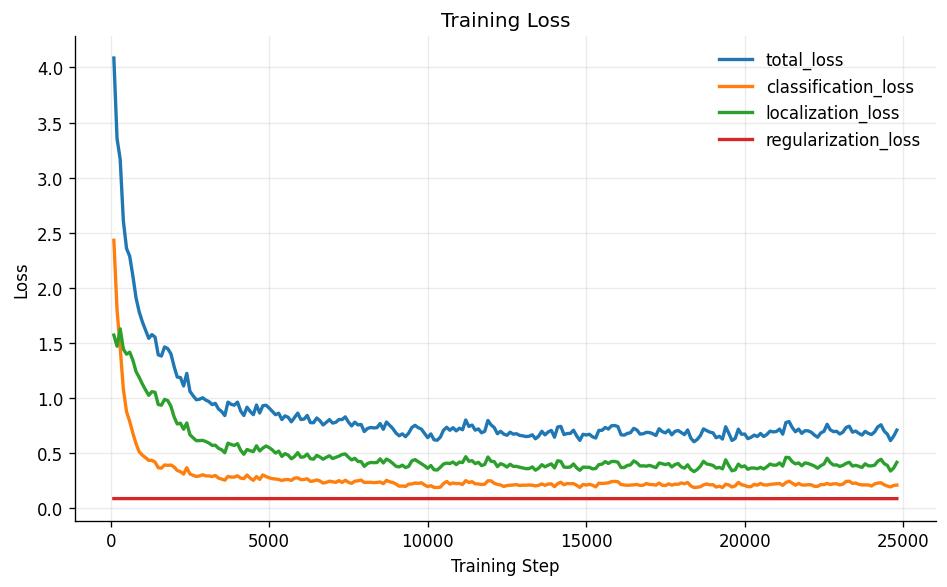

In [13]:
loss_fig, _ = plot_loss_curves(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "training_loss_curves.pdf",
)
display(loss_fig)

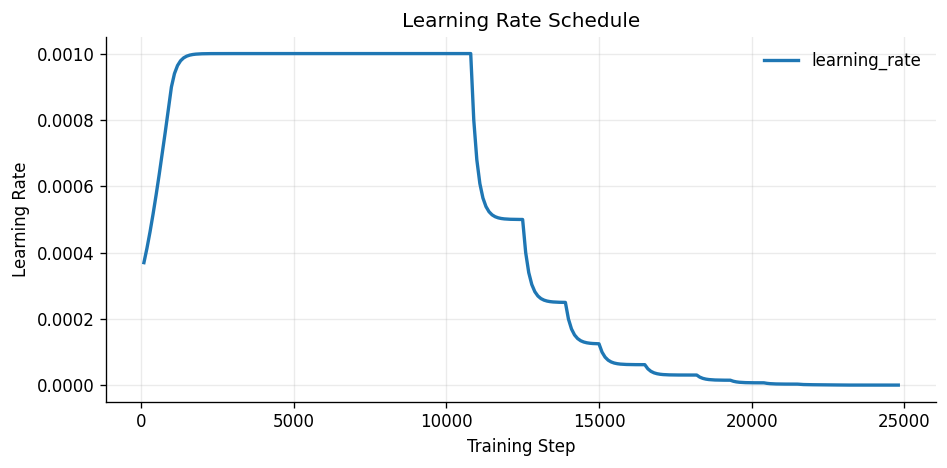

In [14]:
lr_fig, _ = plot_learning_rate(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "learning_rate_schedule.pdf",
)
display(lr_fig)

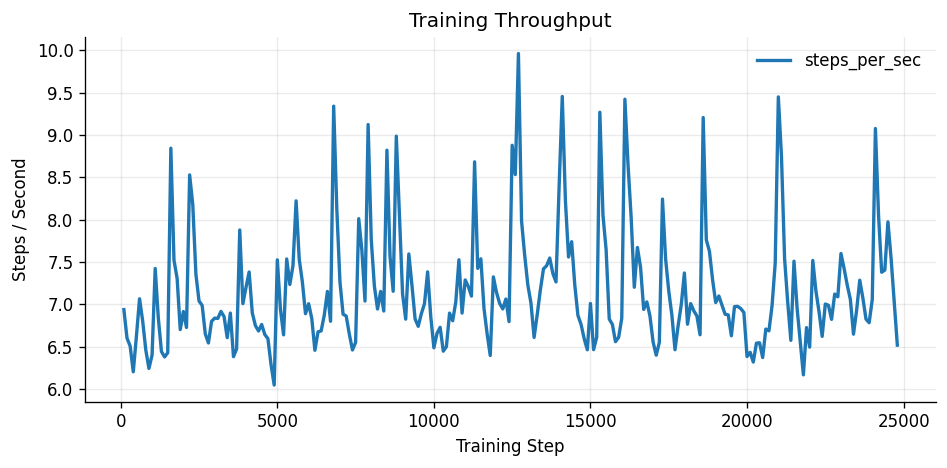

In [15]:
tput_fig, _ = plot_steps_per_second(
    history_df, smoothing=0.5,
    save_path=GRAPHS_PATH / "training_throughput.pdf",
)
display(tput_fig)

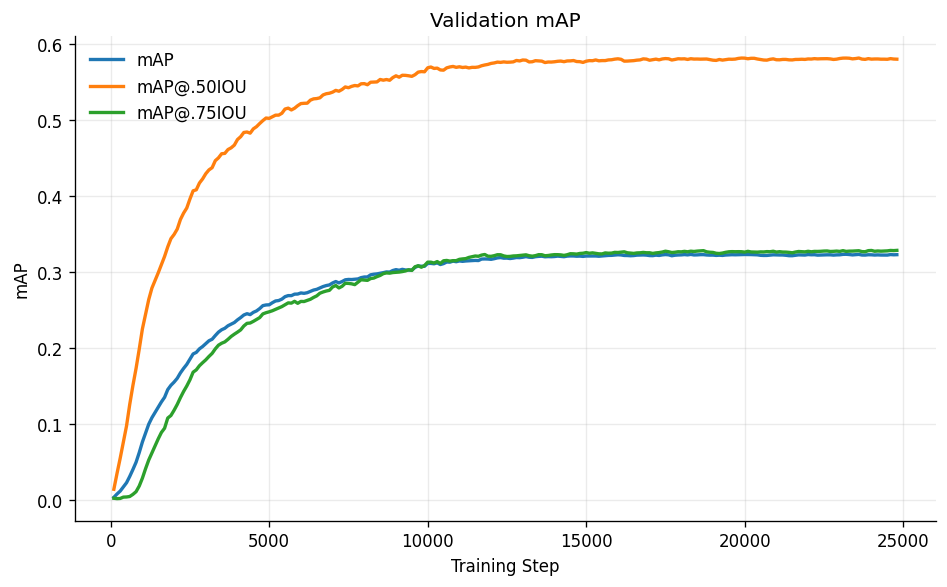

In [16]:
map_fig, _ = plot_map_curves(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_precision_curves.pdf",
)
display(map_fig)

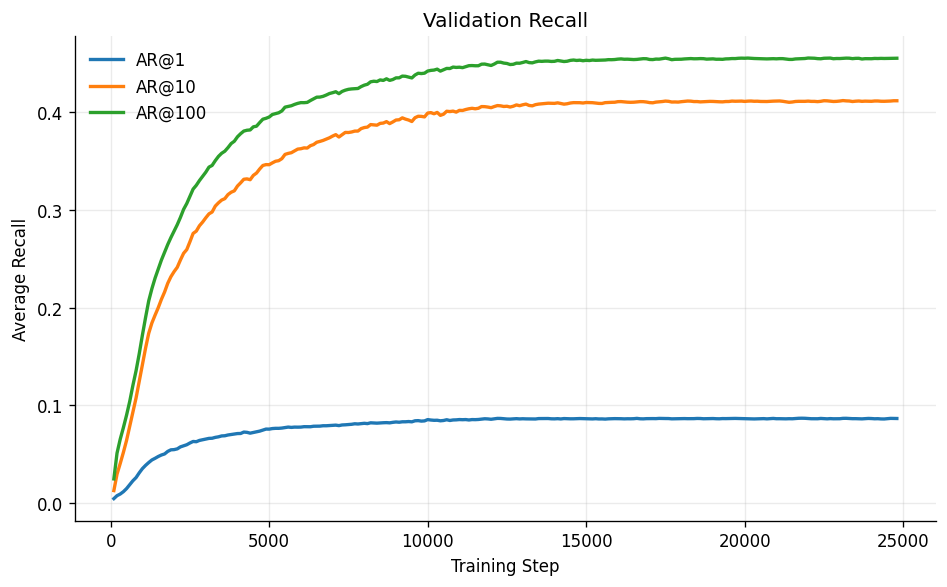

In [17]:
recall_fig, _ = plot_recall_curves(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_recall_curves.pdf",
)
display(recall_fig)

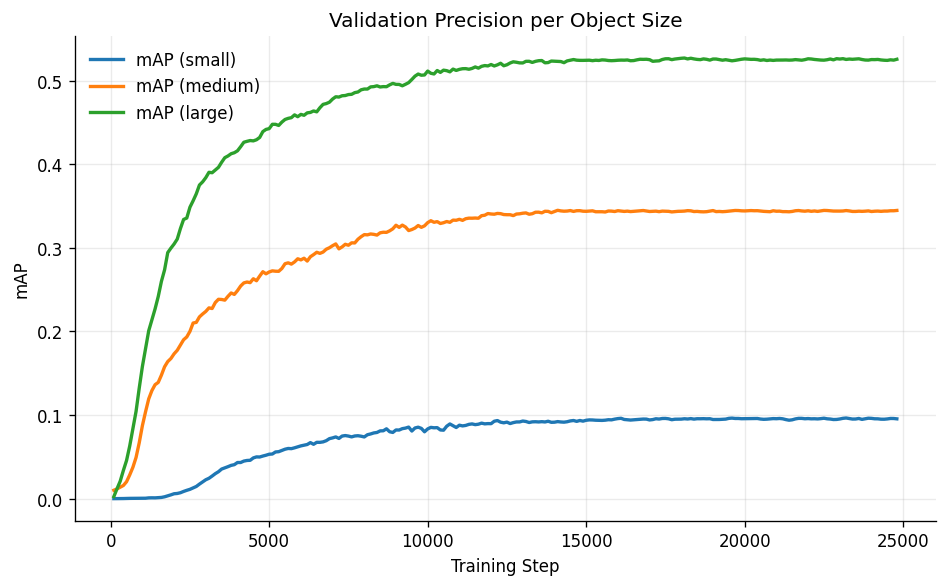

In [18]:
size_precision_fig, _ = plot_metric_curves(
    df=history_df,
    tags=[
        "DetectionBoxes_Precision/mAP (small)",
        "DetectionBoxes_Precision/mAP (medium)",
        "DetectionBoxes_Precision/mAP (large)",
    ],
    title="Validation Precision per Object Size",
    ylabel="mAP",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_precision_size_curves.pdf",
)
display(size_precision_fig)

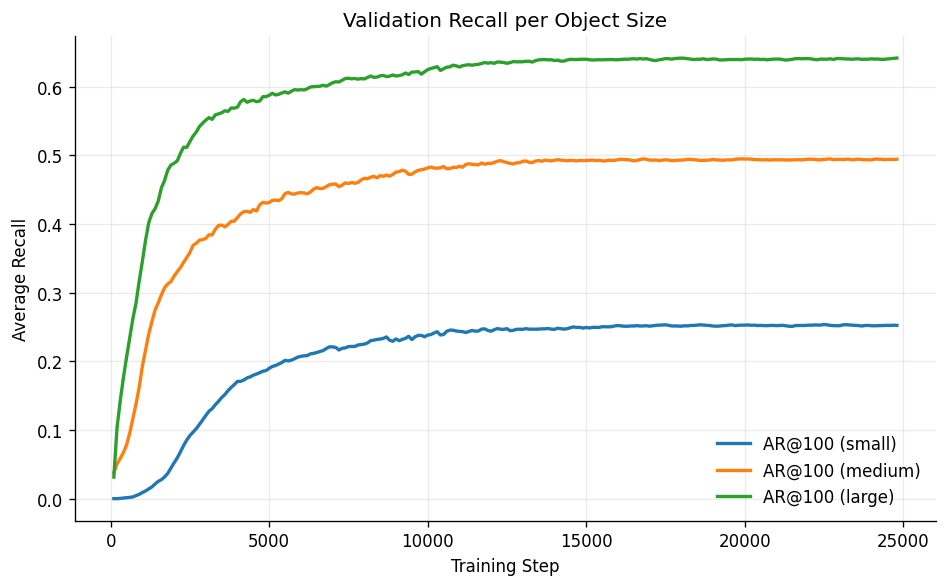

In [19]:
size_recall_fig, _ = plot_metric_curves(
    df=history_df,
    tags=[
        "DetectionBoxes_Recall/AR@100 (small)",
        "DetectionBoxes_Recall/AR@100 (medium)",
        "DetectionBoxes_Recall/AR@100 (large)",
    ],
    title="Validation Recall per Object Size",
    ylabel="Average Recall",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_recall_size_curves.pdf",
)
display(size_recall_fig)

## 9 · Export

`export_run` writes the best checkpoint to the standard TF model-zoo layout
directly into `finetune/` (`checkpoint/ckpt-0.*`, `pipeline.config`, `saved_model/`).
The exported `checkpoint/` + `pipeline.config` is itself a valid `model_path`,
which is exactly how the companion PTQ / QAT notebooks resume from this finetune.

In [20]:
export_result = export_run(run_config, export_dir=FINETUNE_DIR)

print("finetune dir:", export_result.export_dir)
print("SavedModel:", export_result.saved_model_dir)
print("Checkpoint:", export_result.checkpoint)
print("Pipeline:  ", export_result.pipeline_config)

finetune dir: /kaggle/working/finetune
SavedModel: /kaggle/working/finetune/saved_model
Checkpoint: /kaggle/working/finetune/checkpoint/ckpt-0
Pipeline:   /kaggle/working/finetune/pipeline.config


## 10 · Register artifacts and publish

In [21]:
manifest.add_artifact("finetune/pipeline.config", artifact_type="pipeline_config", stage="finetune")
manifest.add_artifact("finetune/graphs", artifact_type="evaluation_plots", stage="finetune")
manifest.add_artifact("finetune/saved_model", artifact_type="tfod_saved_model", stage="finetune")
manifest.add_artifact("finetune/checkpoint", artifact_type="tfod_checkpoint", stage="finetune")

manifest.save(MANIFEST_PATH)

# Drop the scratch run dir so /kaggle/working == {manifest.json, finetune/}.
shutil.rmtree(RUN_DIR, ignore_errors=True)

print("Published:")
for p in sorted(WORK.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(WORK))

Published:
  __notebook__.ipynb
  finetune/best_metric.json
  finetune/checkpoint/checkpoint
  finetune/checkpoint/ckpt-0.data-00000-of-00001
  finetune/checkpoint/ckpt-0.index
  finetune/graphs/eval_precision_curves.pdf
  finetune/graphs/eval_precision_size_curves.pdf
  finetune/graphs/eval_recall_curves.pdf
  finetune/graphs/eval_recall_size_curves.pdf
  finetune/graphs/learning_rate_schedule.pdf
  finetune/graphs/training_loss_curves.pdf
  finetune/graphs/training_throughput.pdf
  finetune/metrics_history.json
  finetune/pipeline.config
  finetune/saved_model/fingerprint.pb
  finetune/saved_model/saved_model.pb
  finetune/saved_model/variables/variables.data-00000-of-00001
  finetune/saved_model/variables/variables.index
  manifest.json


## 11 · Qualitative evaluation

Predictions on unseen PhenoBench test images, using the exported fp32
SavedModel from `finetune/`.

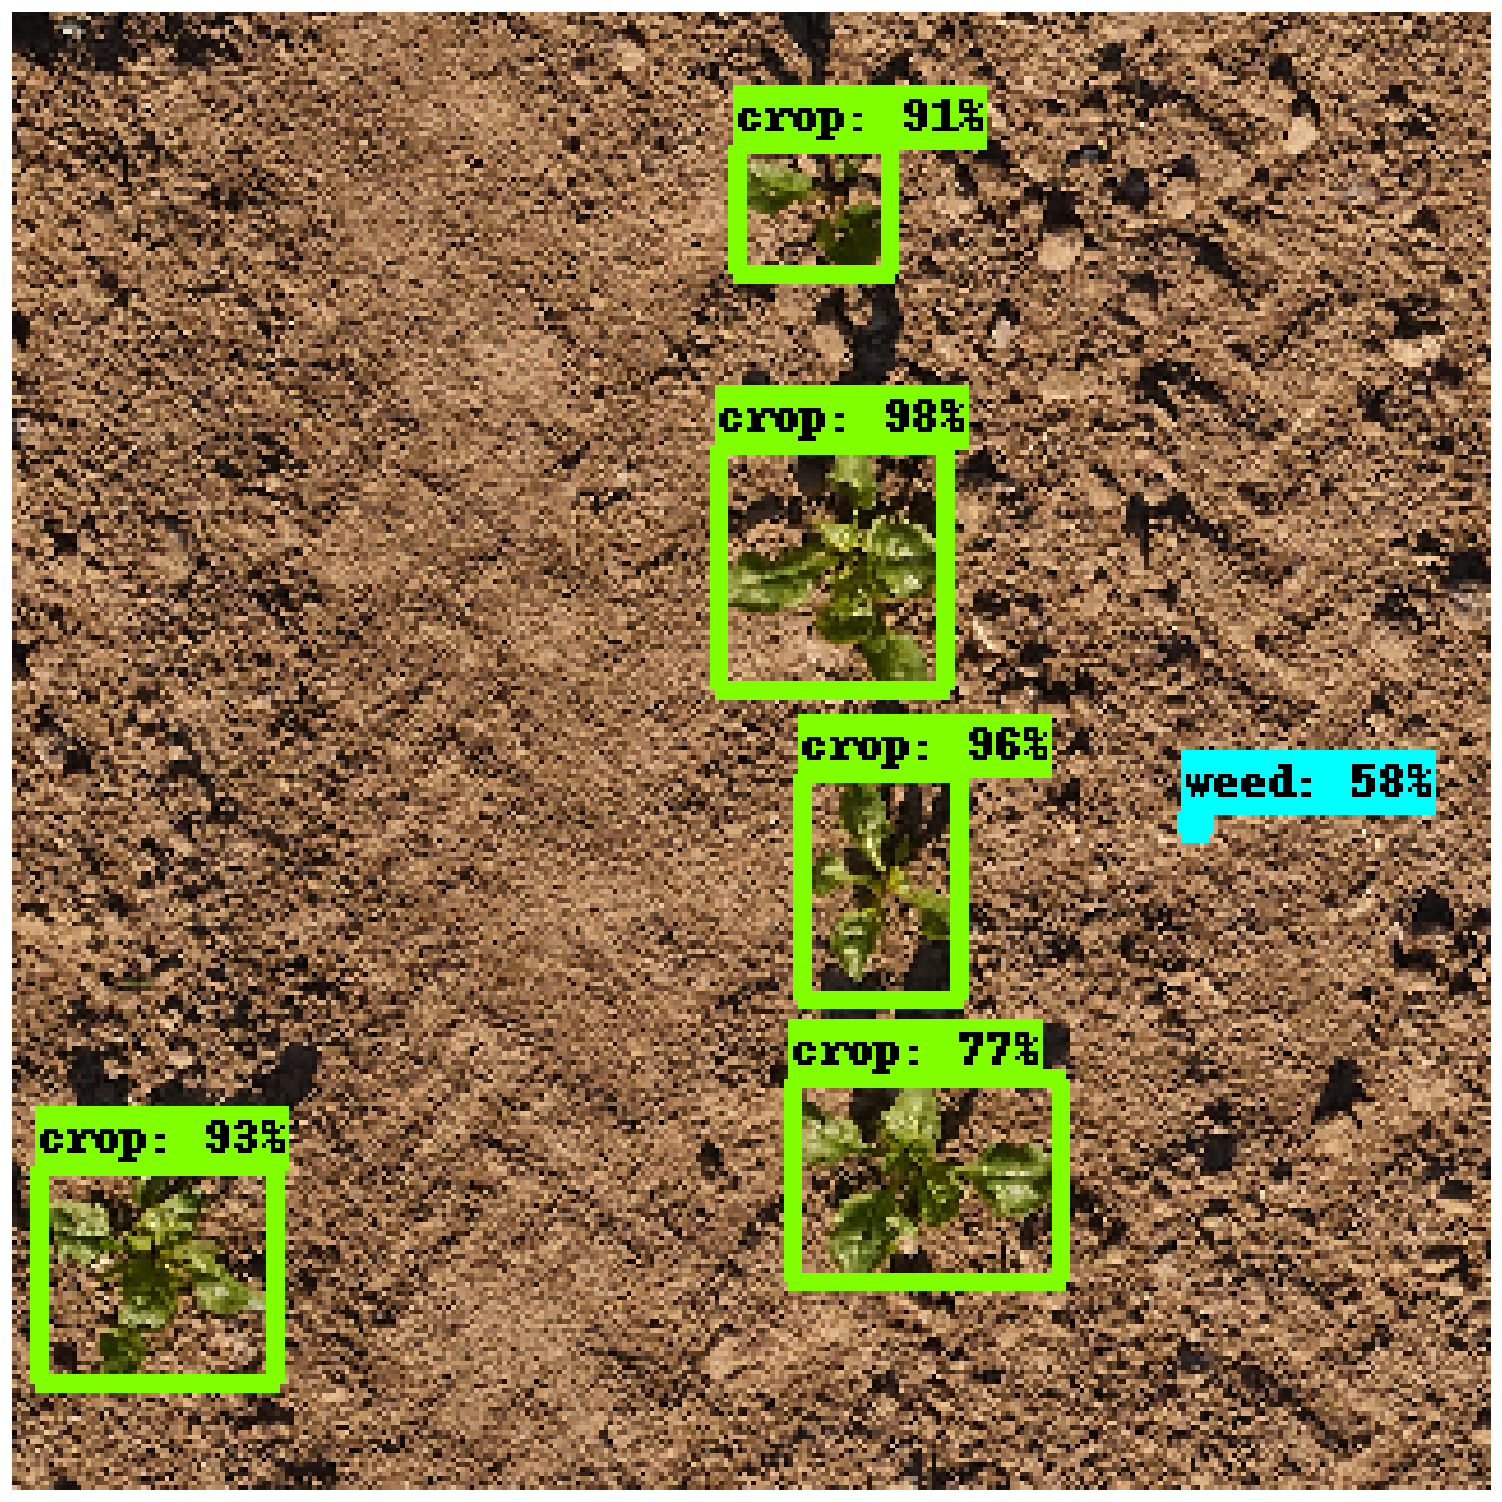

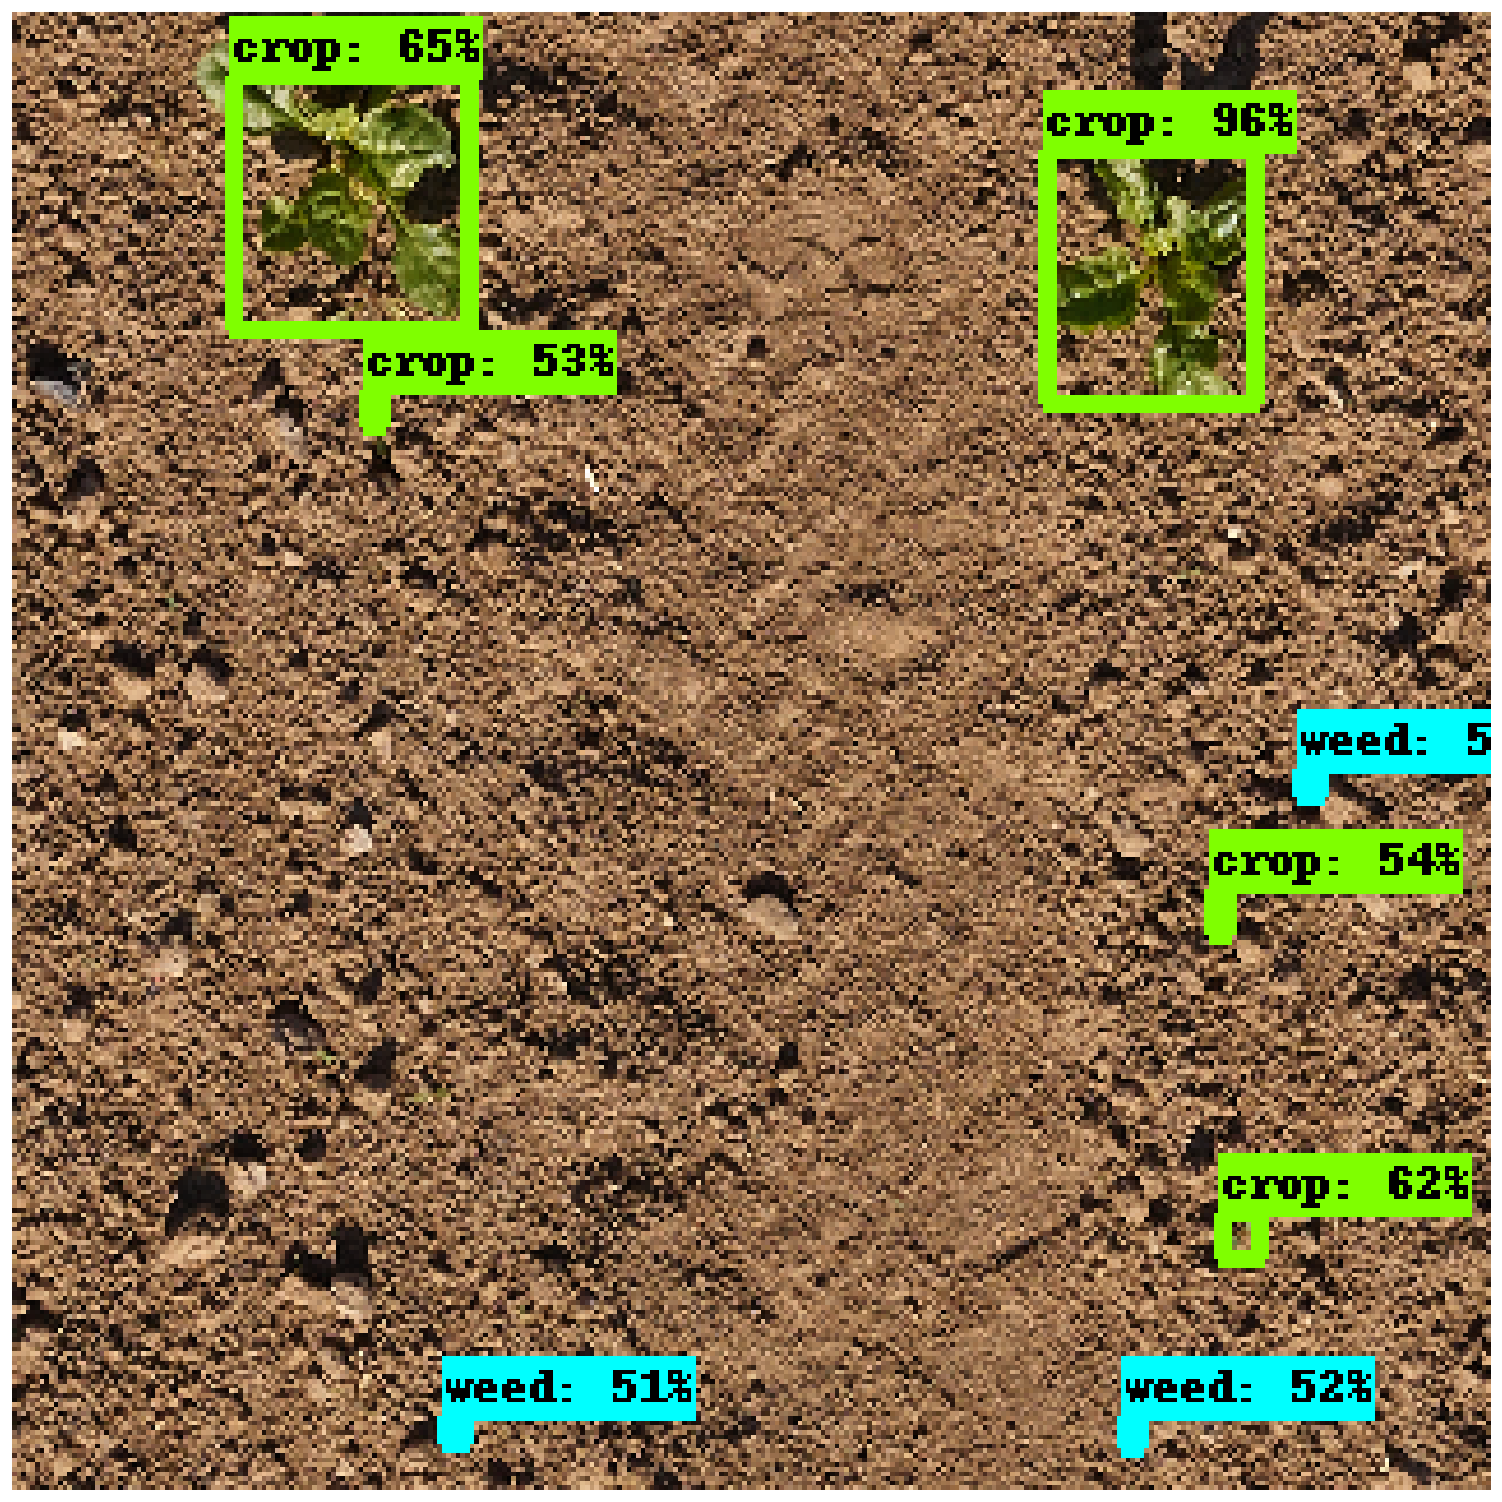

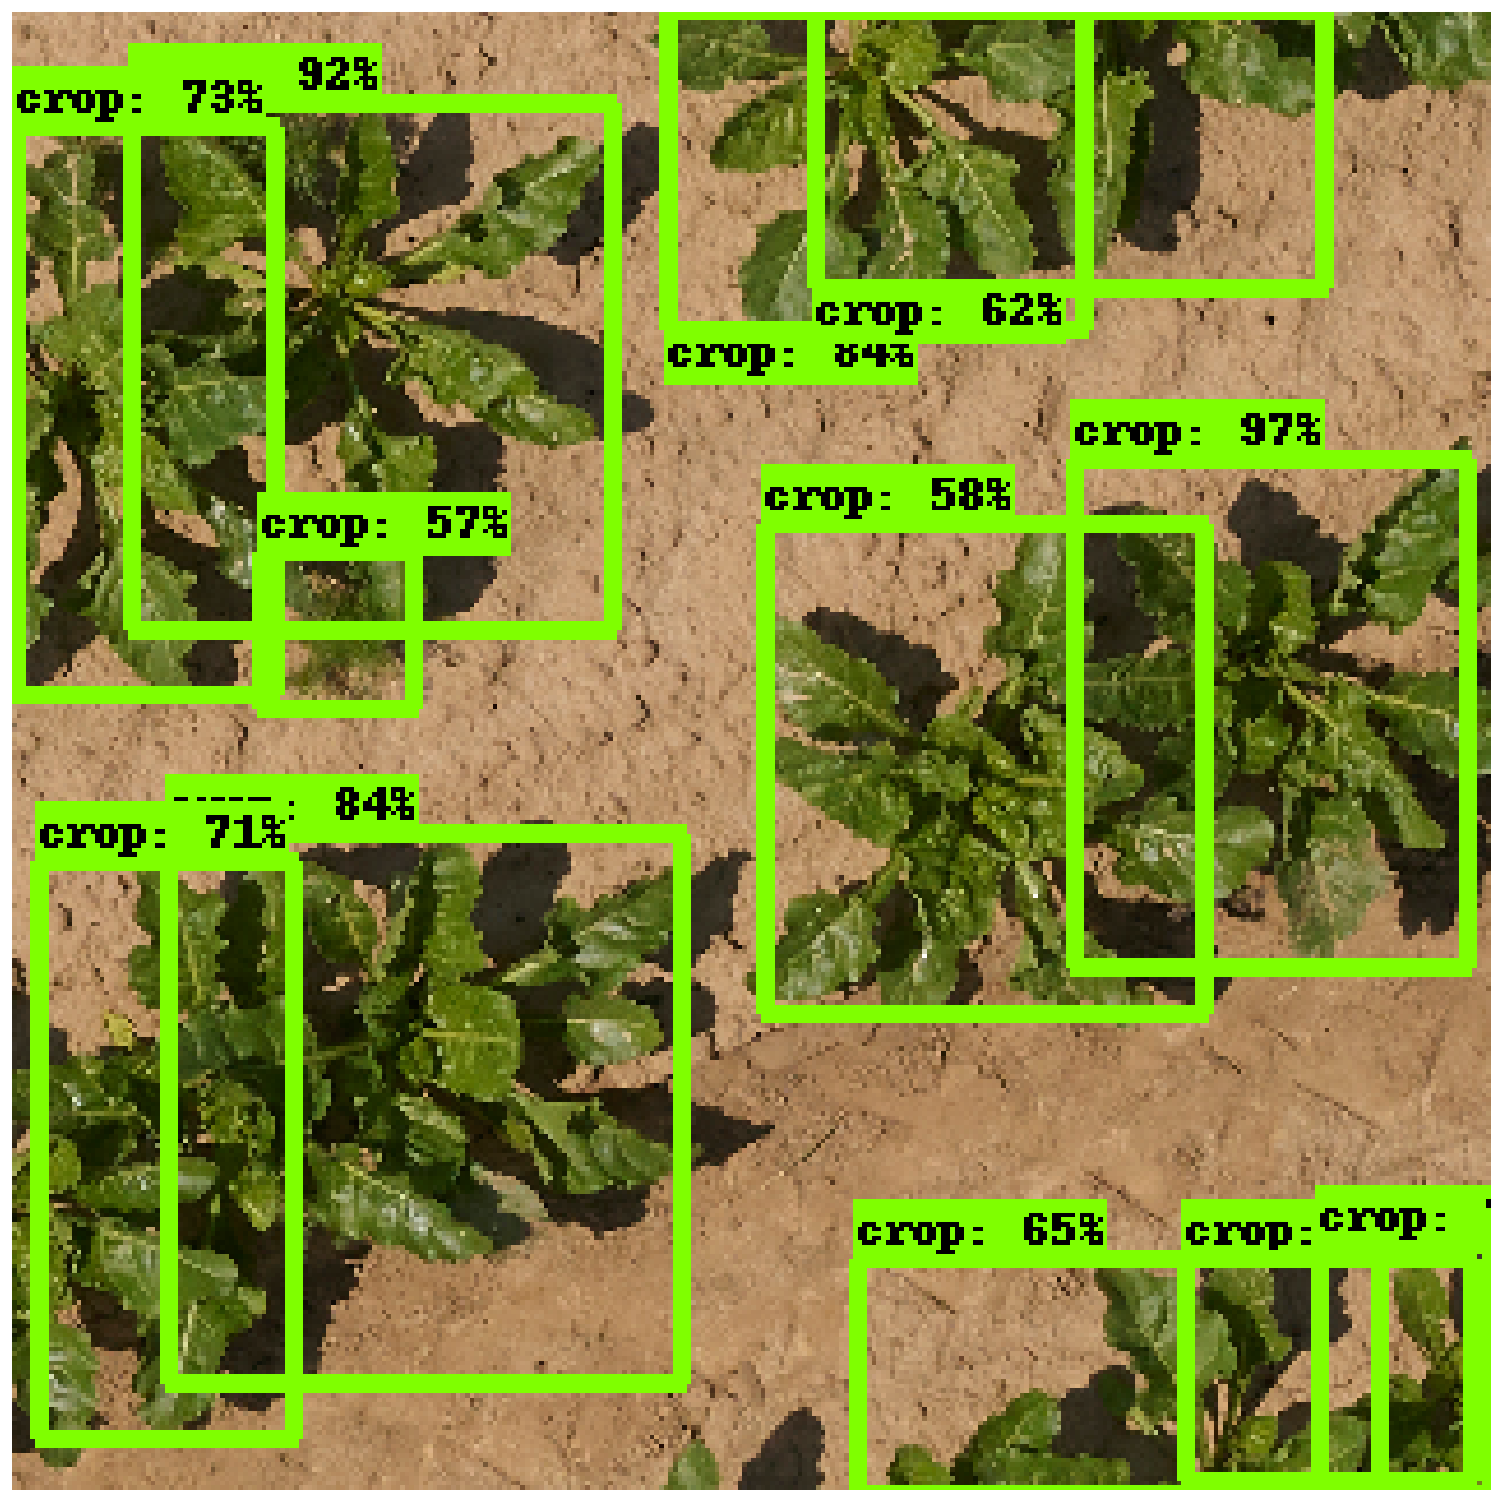

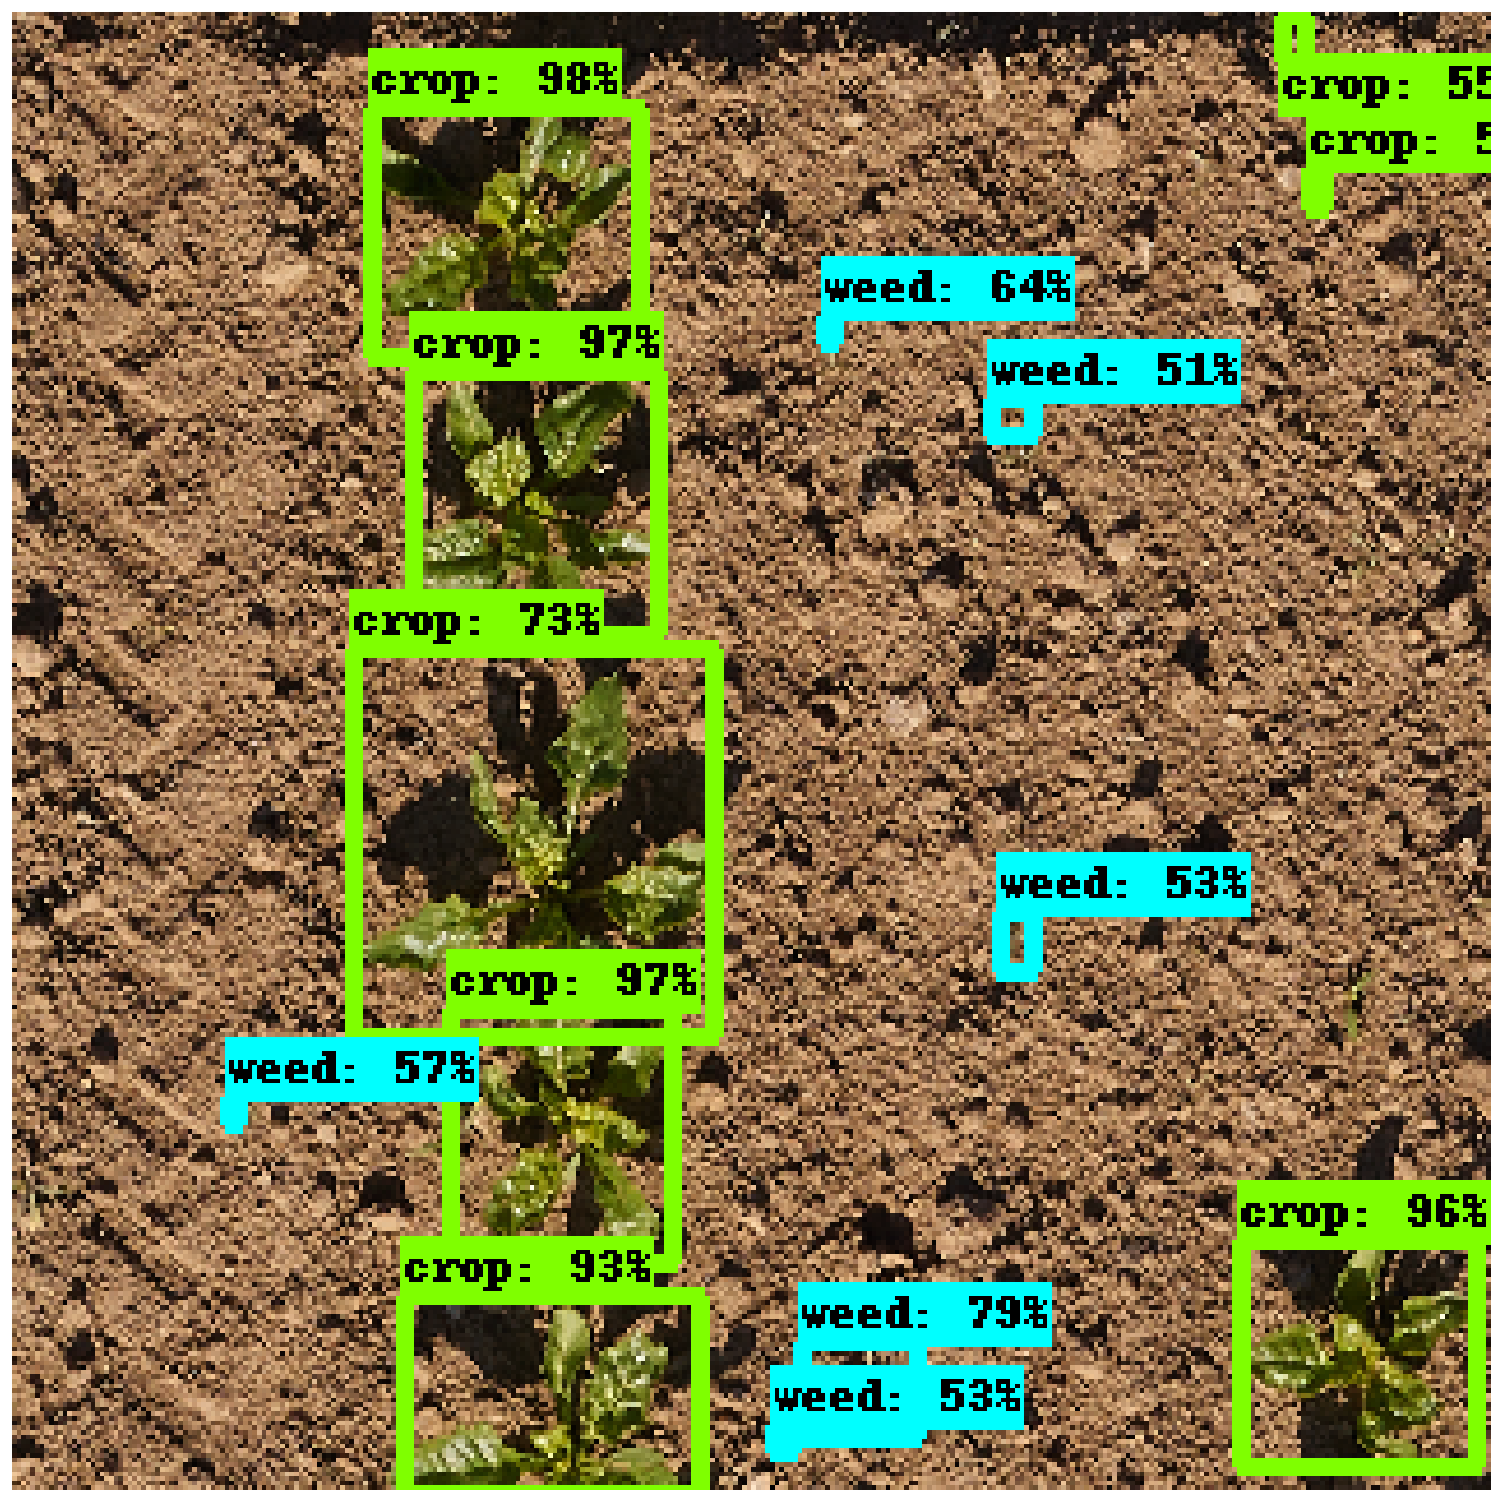

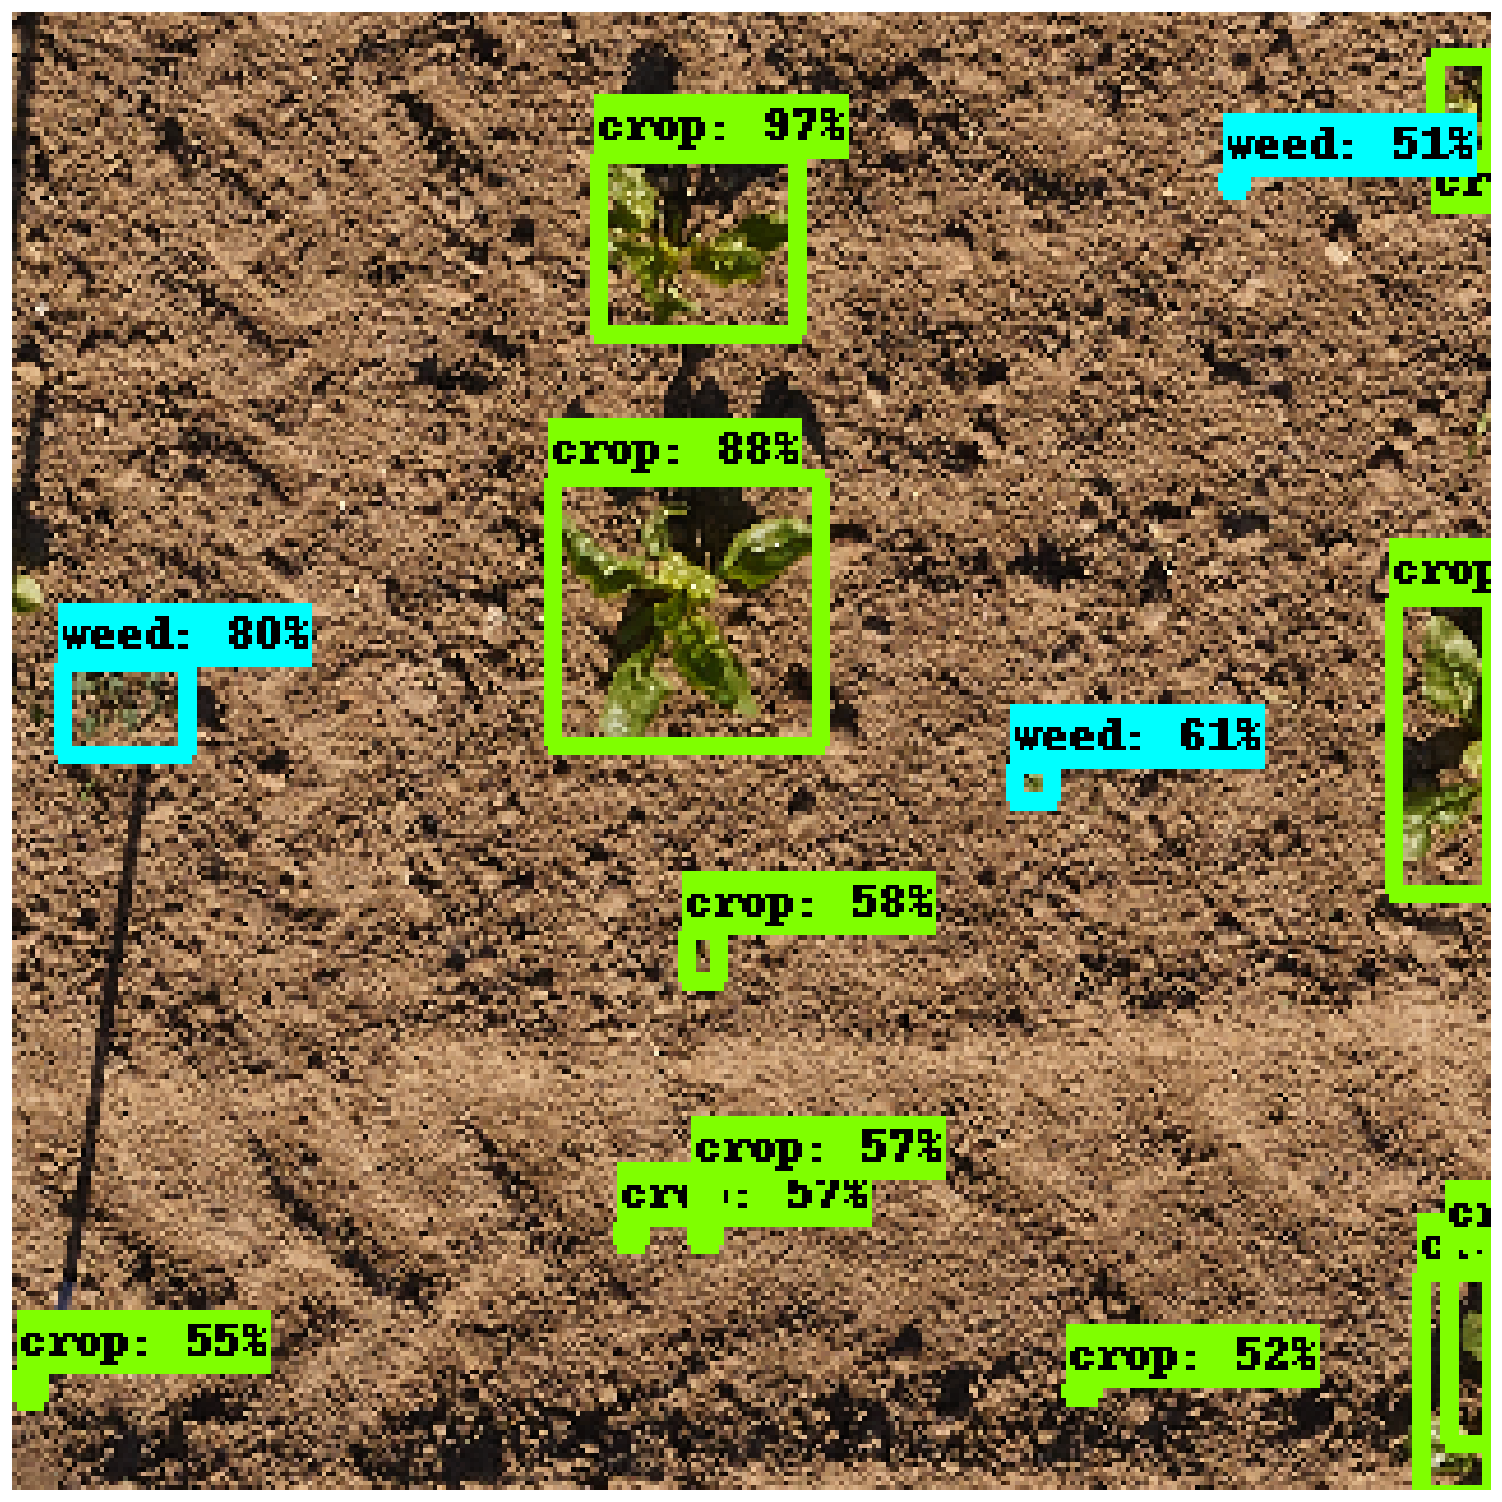

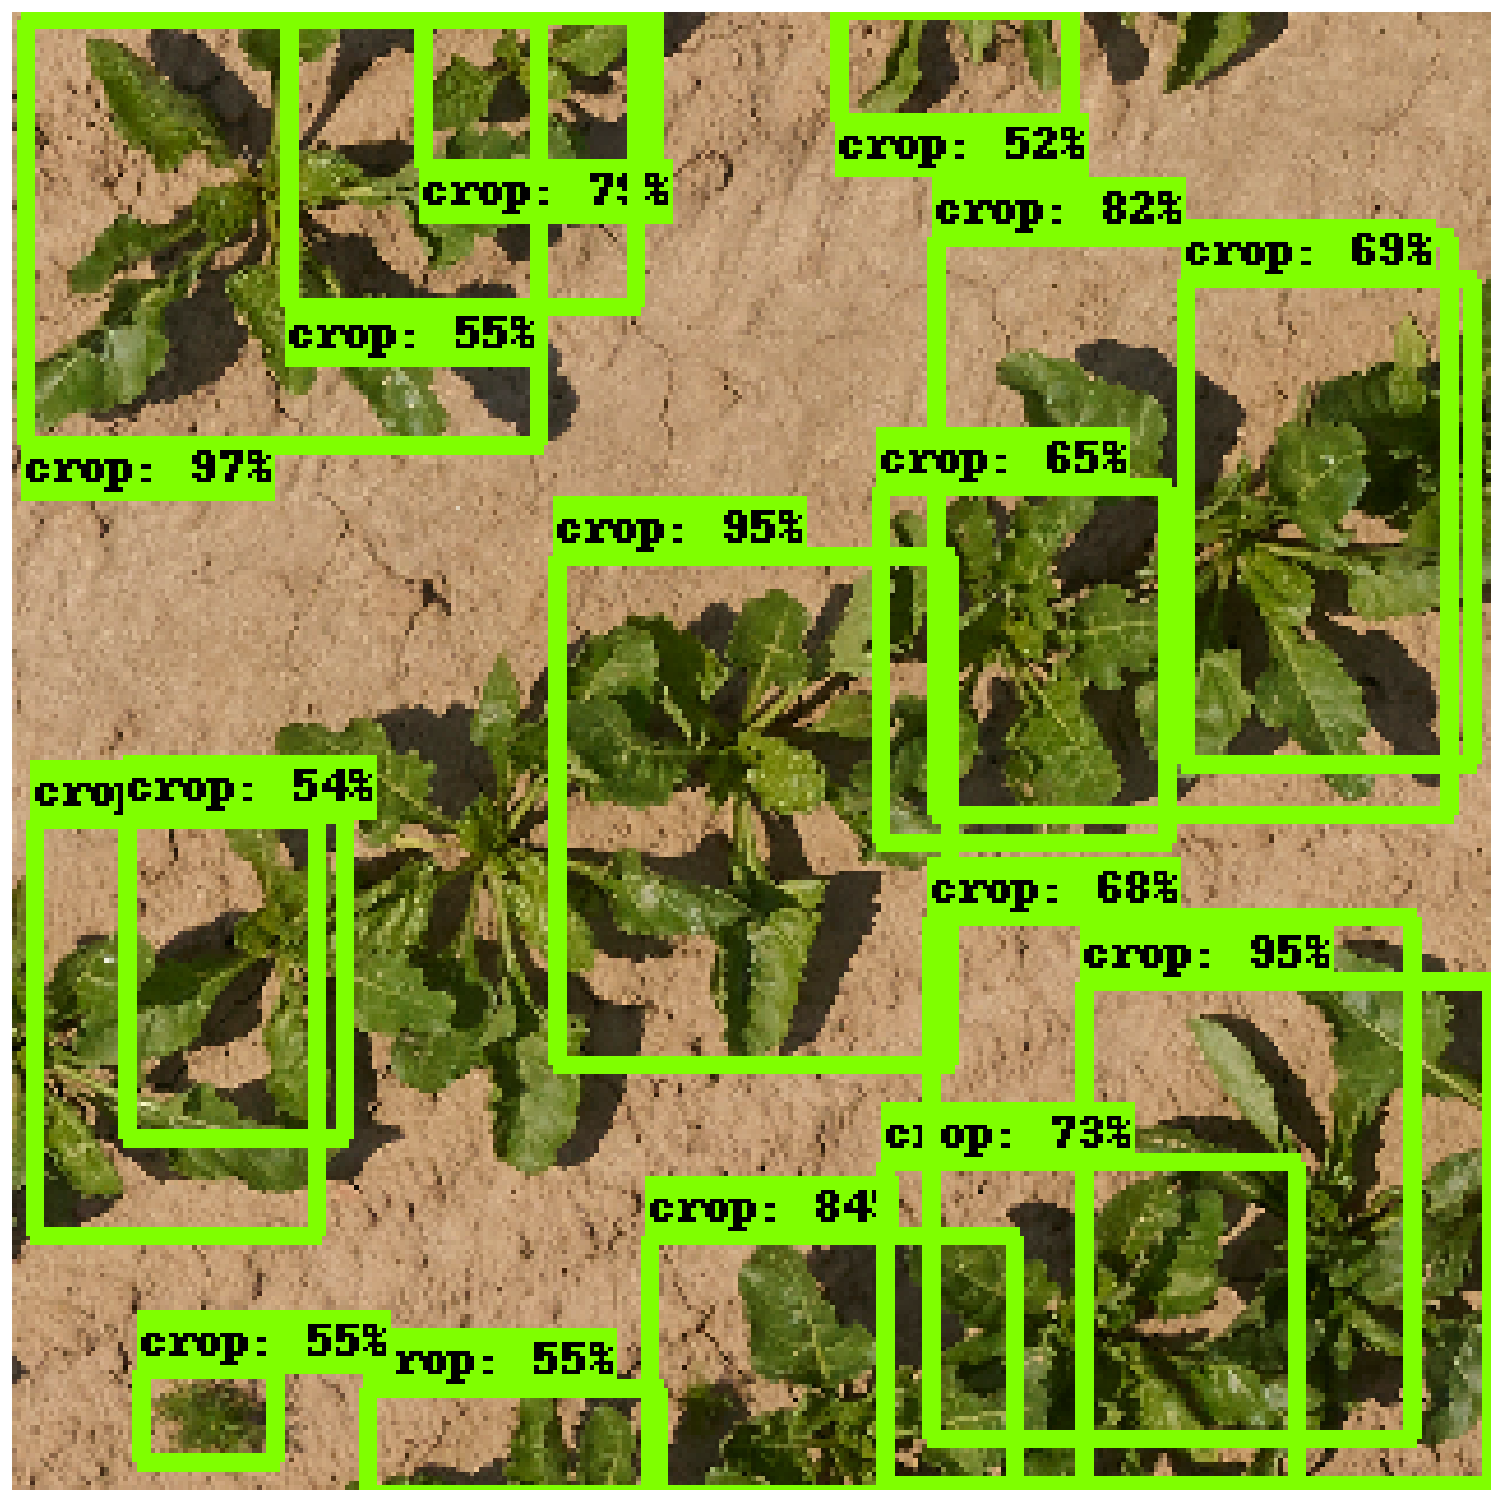

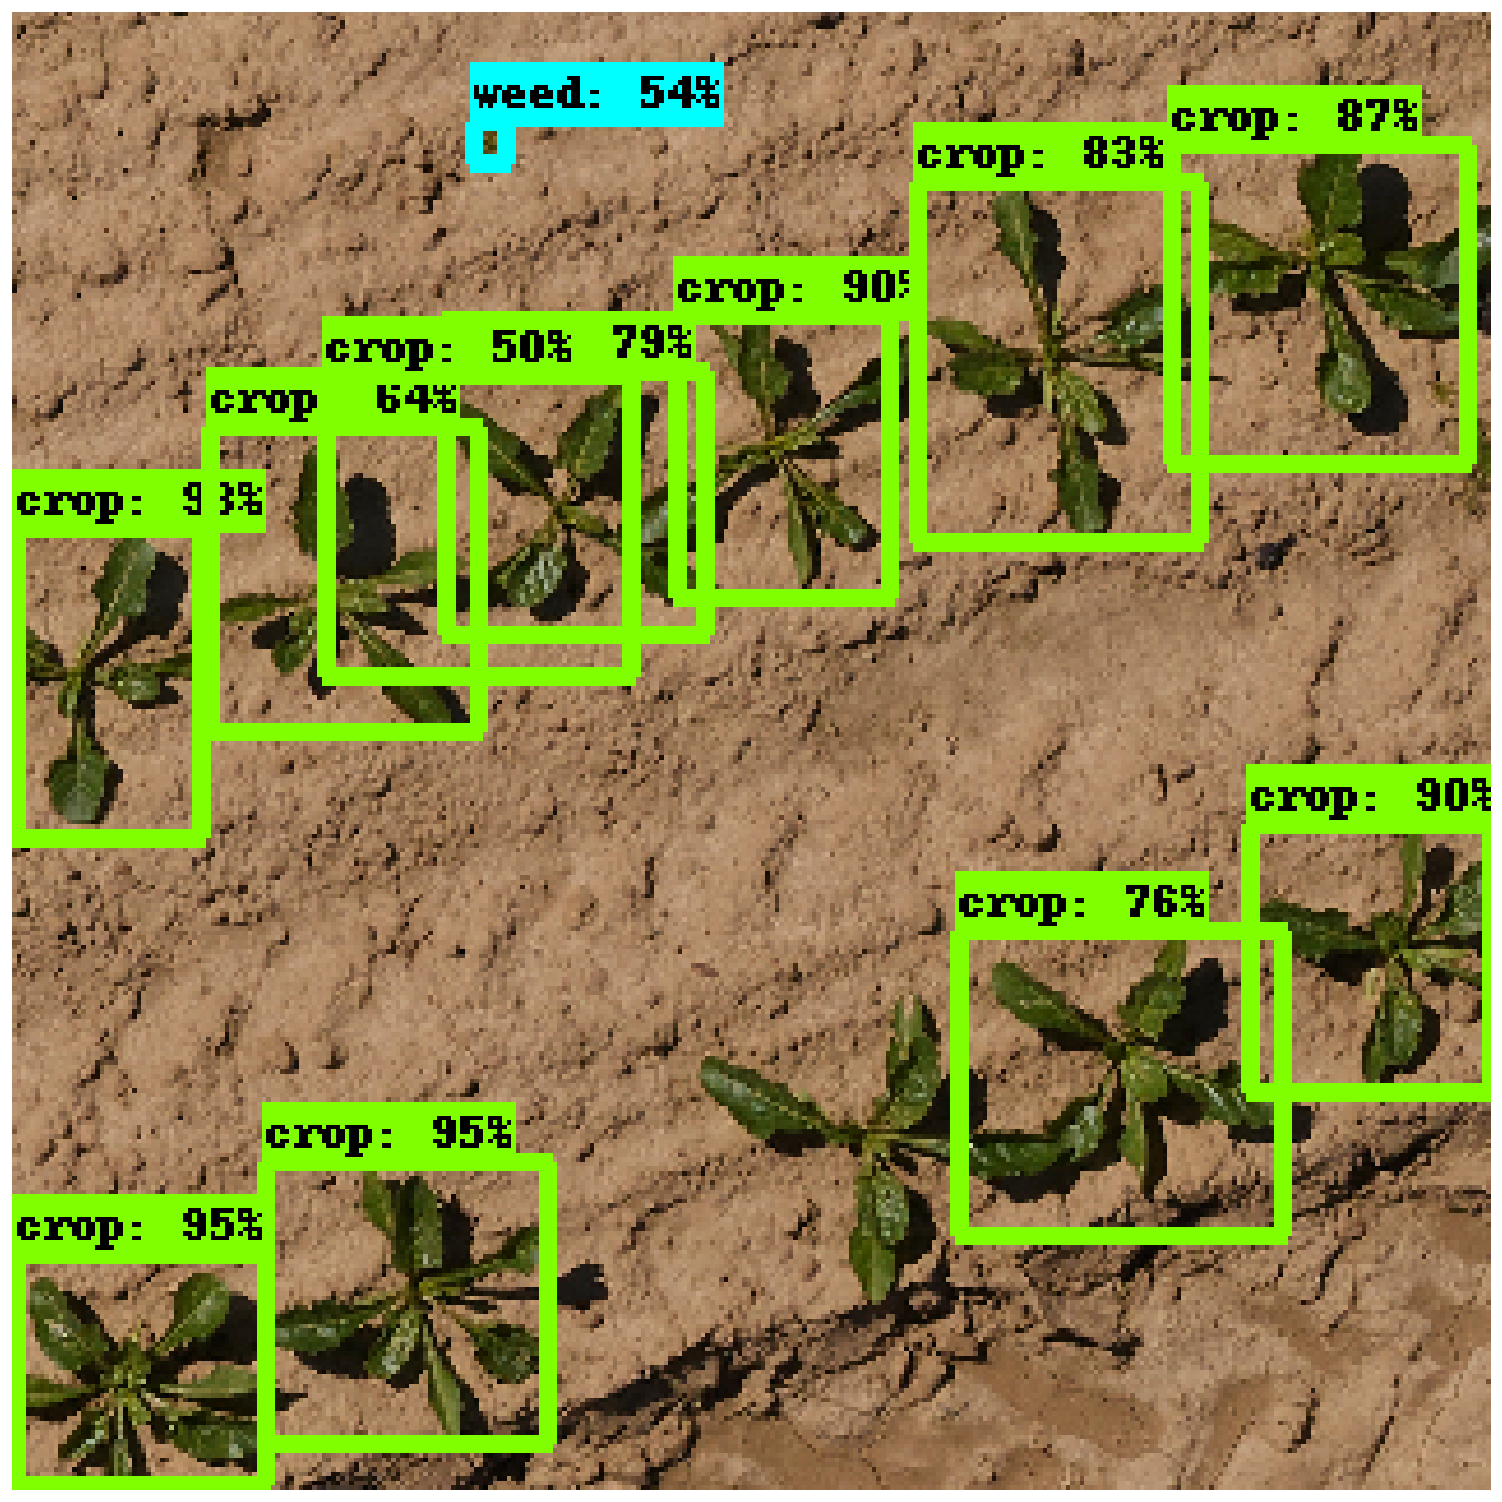

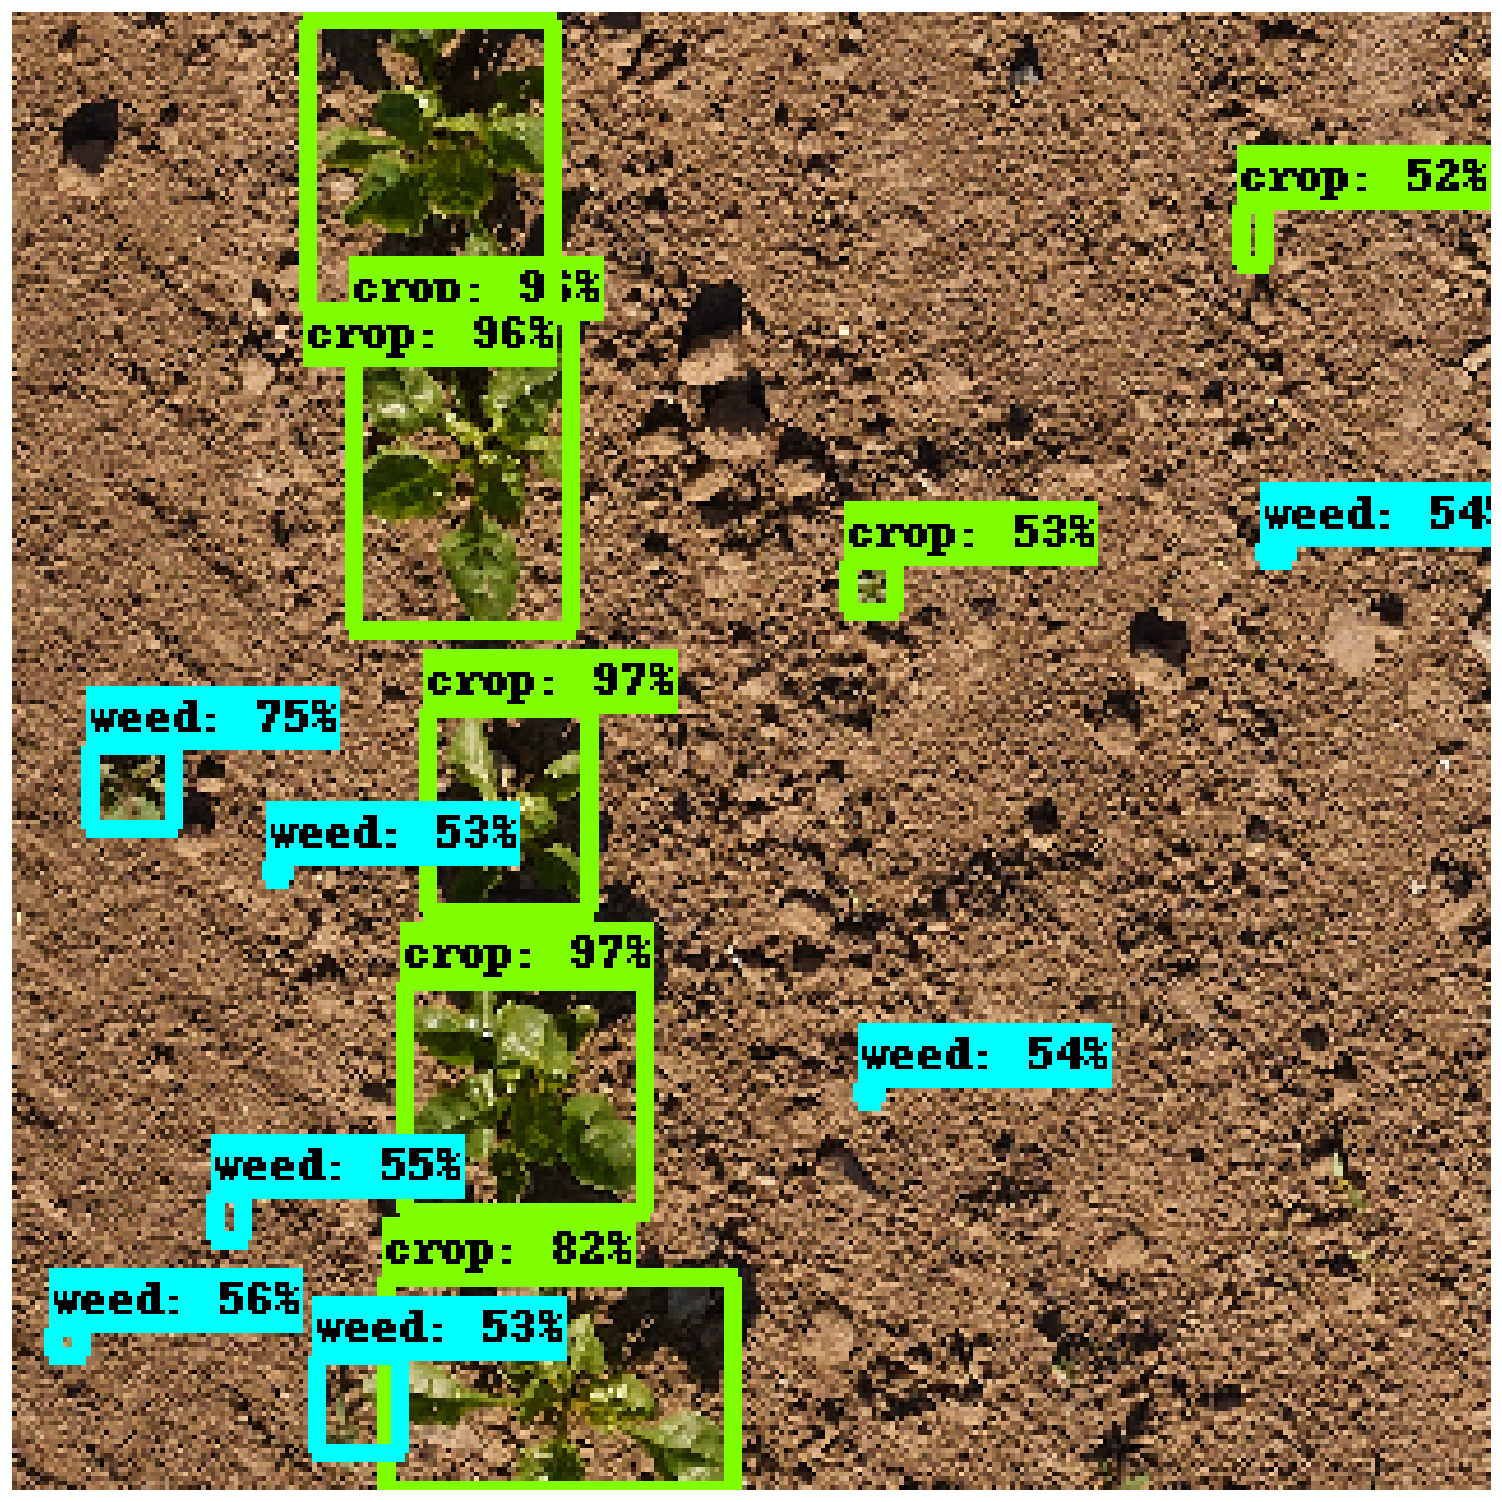

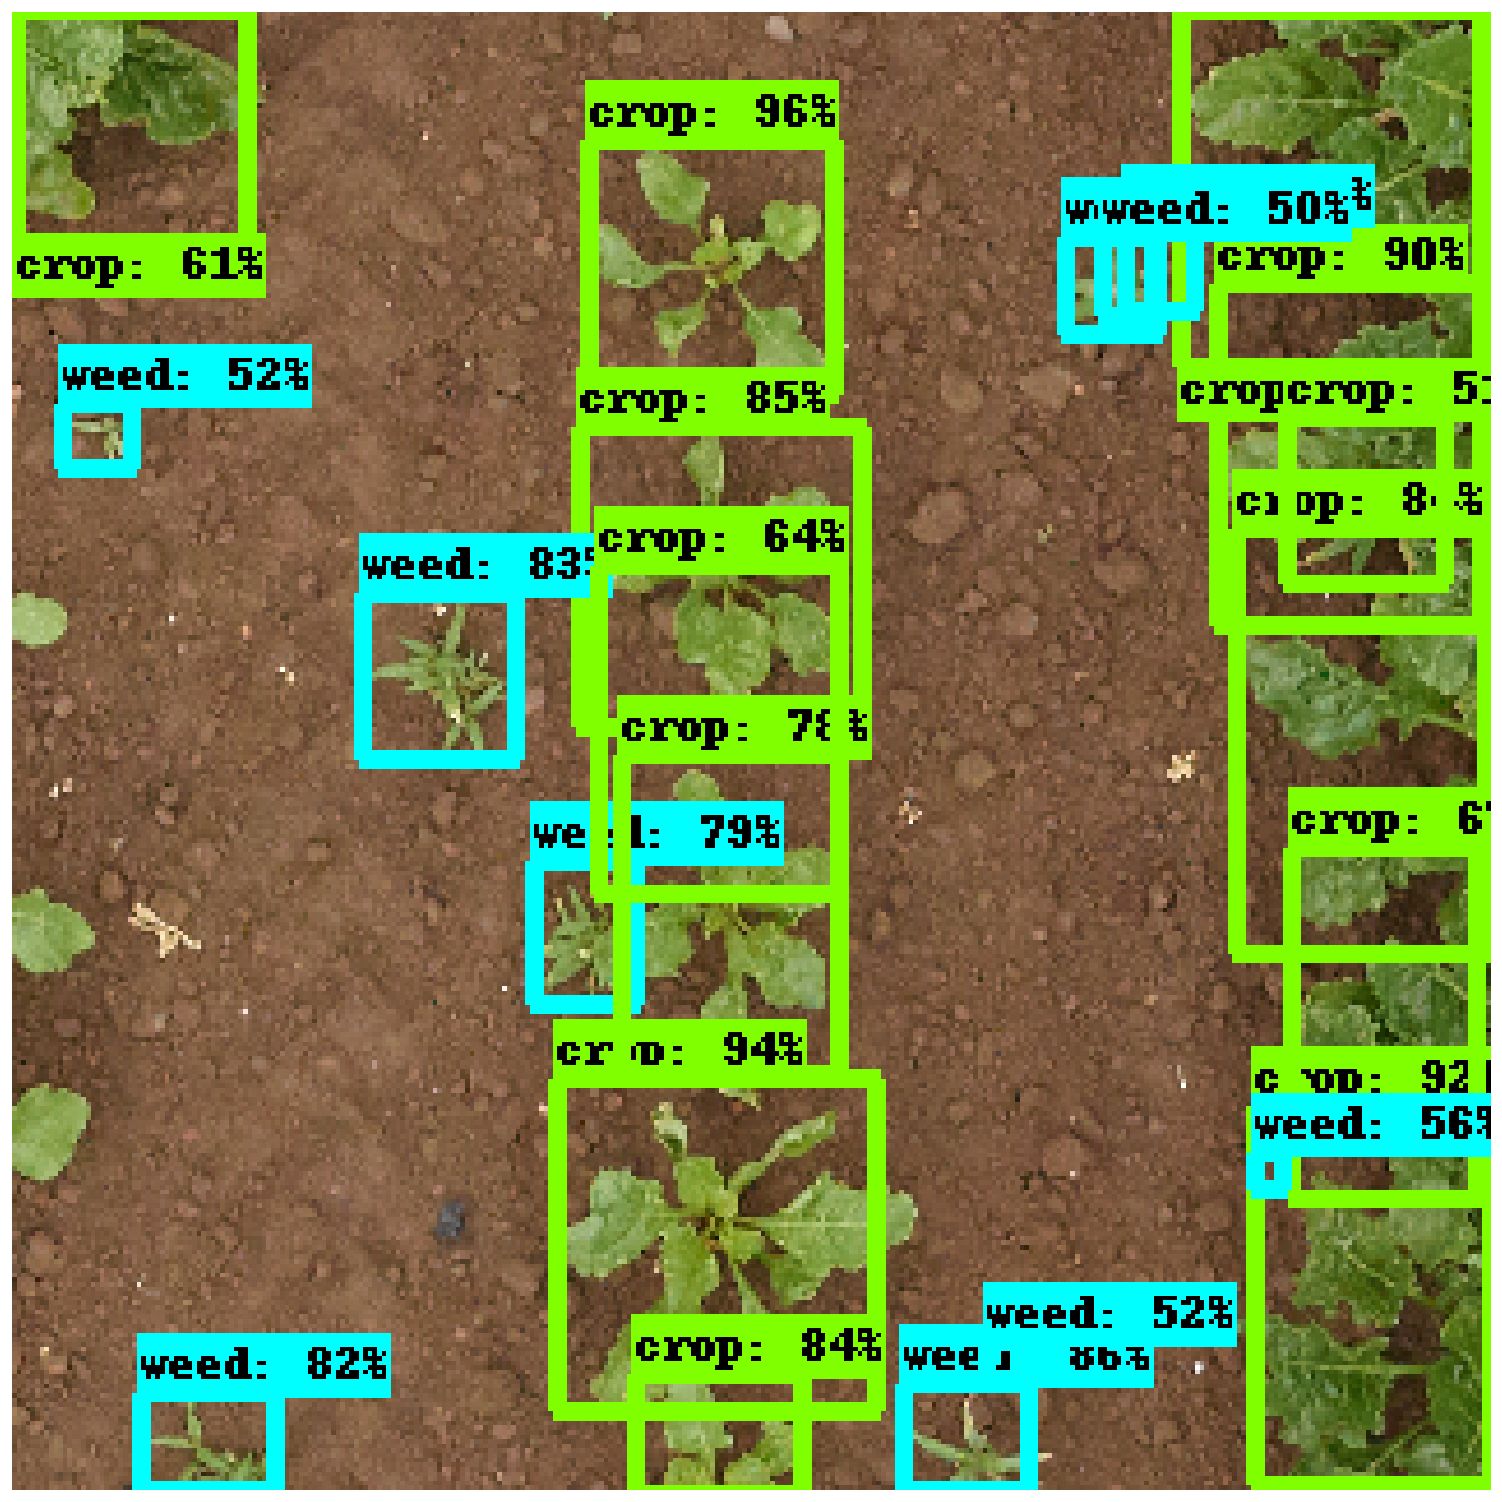

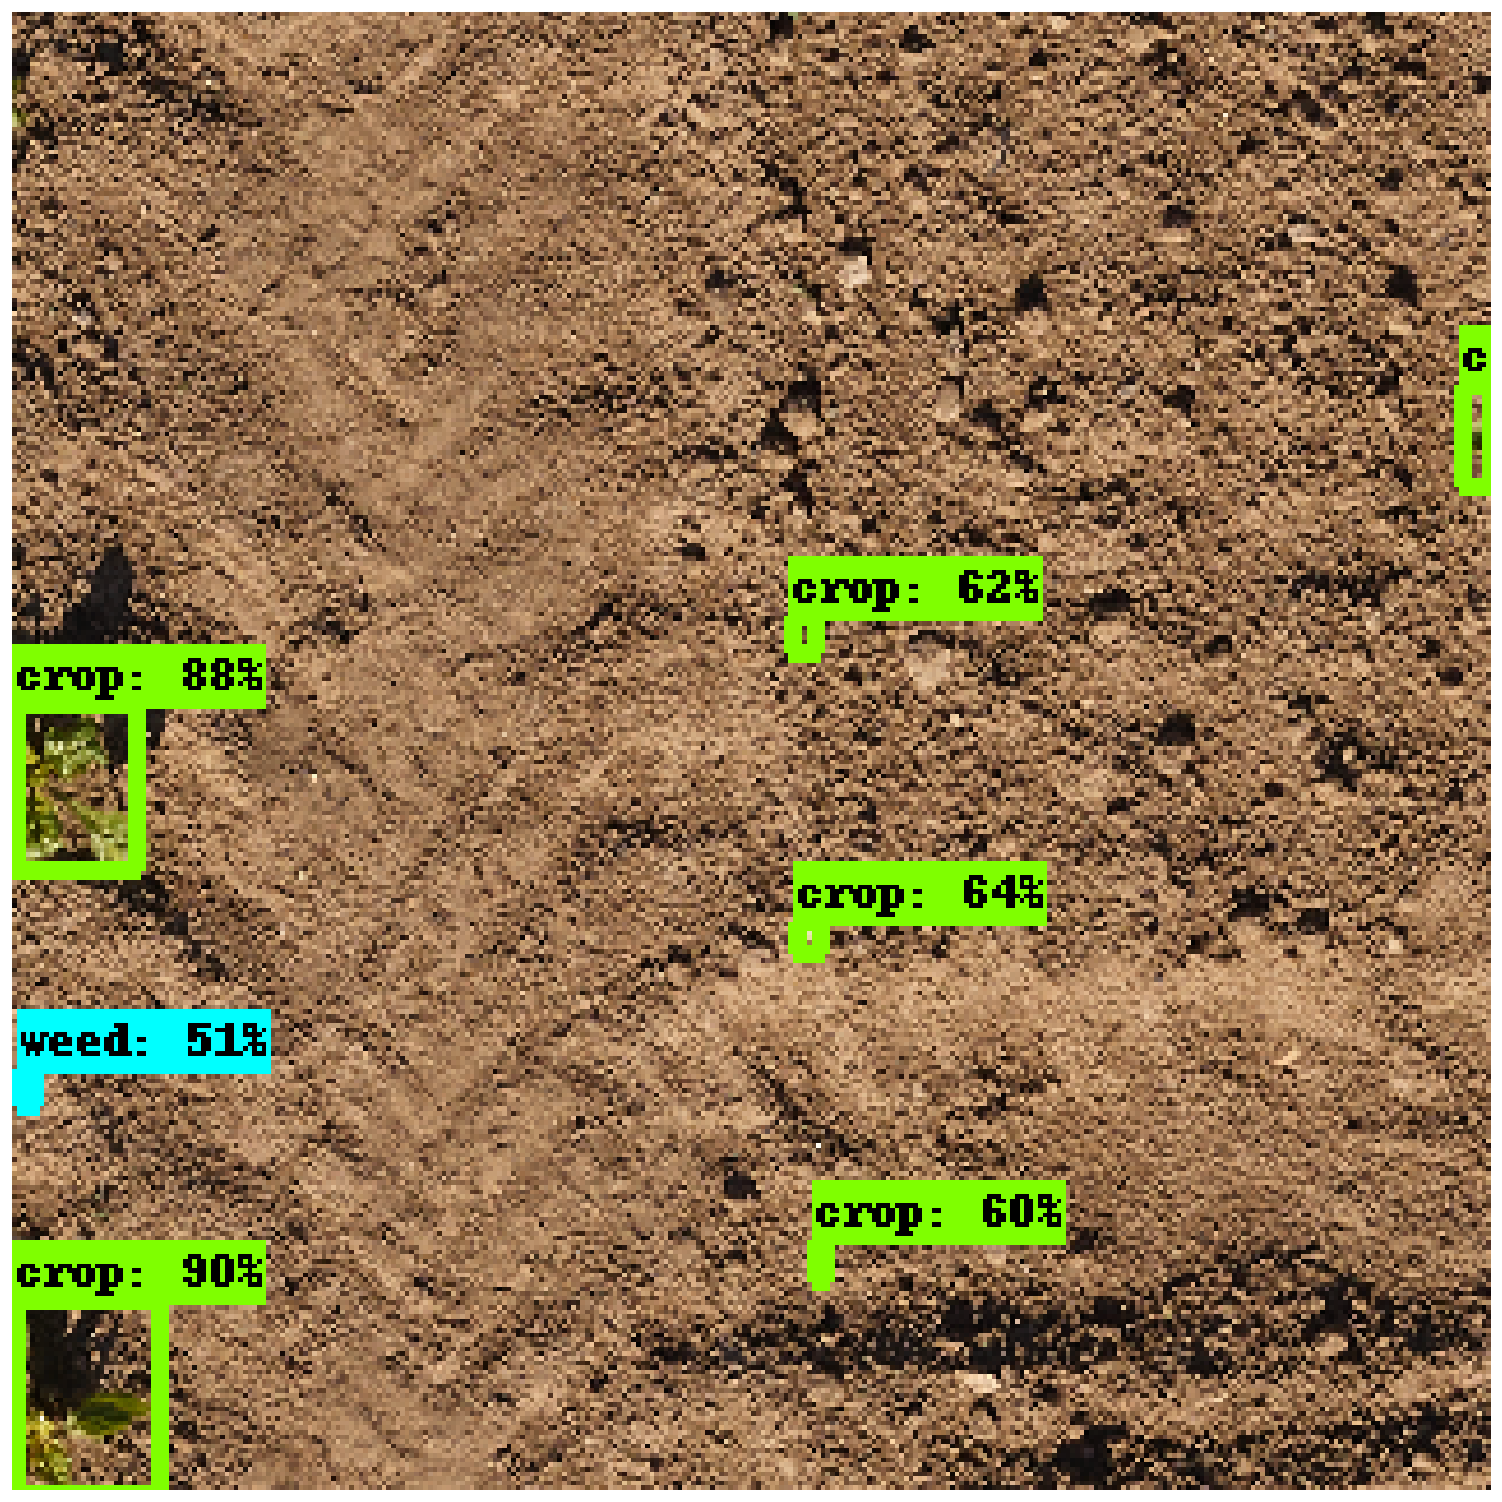

In [22]:
%matplotlib inline

from agri_vision_edge.tfod.inference import (
    load_saved_model,
    load_label_map,
    detect_image,
)

detect_fn = load_saved_model(str(FINETUNE_DIR / "saved_model"))
category_index = load_label_map(label_map_path)

for image_path in test_imgs[:10]:
    vis, _ = detect_image(
        detect_fn=detect_fn,
        image_path=image_path,
        category_index=category_index,
        image_size=config.image_size,
        score_threshold=0.5,
        max_boxes=60,
    )
    plt.figure(figsize=(16, 16))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()
    plt.close()

## 12 · Discussion

Qualitatively the model localizes individual plant instances and suppresses
overlapping detections via NMS; small instances remain the hardest case, as the
per-size curves above make explicit.

Next steps:
- **Quantization-aware training:** the companion `qatN` notebooks resume from
  this `finetune/` export with a `qat_scheme` set.
- **INT8 TFLite deployment:** `notebooks/tflite_conversion.py` consumes the
  `finetune/`, `ptq/` or a `qatN/` export.